In [1]:
import pyscf
import openfermionpyscf
import openfermion as of
import matplotlib.pyplot as plt
import numpy as np
from tqdm import tqdm
from itertools import combinations

import sys
sys.path.insert(0, "..")

from chemistry import build_h2o_geometry

In [49]:
%%time
geometry = [["N", (0, 0, 0)],
            ["N", (0, 0, 2.0)]]

# geometry = build_h2o_geometry(2., 104.5)

mol = pyscf.M()
mol.build(atom=geometry, basis="sto-6g")

mf = pyscf.scf.RHF(mol)
mf.kernel()
cisolver = pyscf.fci.FCI(mf)
cisolver.kernel()
print()

converged SCF energy = -107.928689936688

CPU times: user 13.6 s, sys: 5.09 s, total: 18.7 s
Wall time: 1.63 s


In [50]:
geometry

[['N', (0, 0, 0)], ['N', (0, 0, 2.0)]]

In [51]:
mol.ao_labels()

['0 N 1s    ',
 '0 N 2s    ',
 '0 N 2px   ',
 '0 N 2py   ',
 '0 N 2pz   ',
 '1 N 1s    ',
 '1 N 2s    ',
 '1 N 2px   ',
 '1 N 2py   ',
 '1 N 2pz   ']

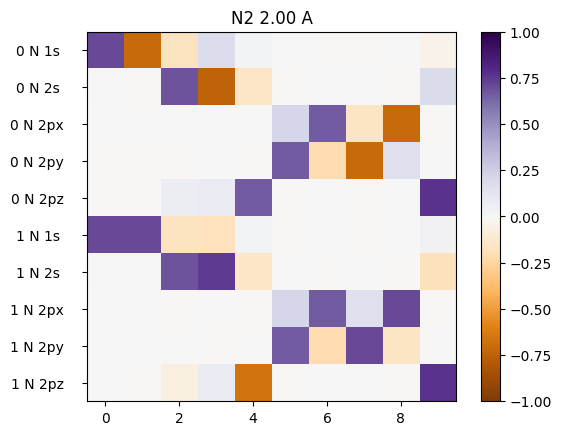

In [53]:
plt.imshow(mf.mo_coeff, cmap="PuOr", vmin=-1, vmax=1)
plt.colorbar()
# title = "Canonical orbitals, H2O bond {0:2.2f} A".format(np.linalg.norm(geometry[1][1]))
title = "N2 {0:2.2f} A".format(geometry[1][1][2])
plt.title(title)
plt.yticks(range(mol.nao), mol.ao_labels())
plt.savefig(title + ".png", format="png", bbox_inches="tight")
plt.show()

In [3]:
cisolver.ci.shape

(120, 120)

In [7]:
# dists = np.linspace(0.5, 2, 8)
dists = np.array([1.089, 2.067, 2.556, 4.022])

orbenes = np.zeros((4, len(dists)))

hf_energies = np.zeros_like(dists)
fci_energies = np.zeros_like(dists)
hf_fci_overlaps = np.zeros_like(dists)

for i, dist in tqdm(enumerate(dists)):

    # geometry = build_h2o_geometry(dist, 150)
    
    # geometry = [["N", (0, 0, 0)],
    #             ["N", (0, 0, dist)]]
    # geometry = [["H", (0, 0, 0)],
    #             ["H", (0, 0, 2 * dist)],
    #             ["O", (0, 0, dist)]
    #             ]
    # geometry = [["Li", (0, 0, 0)],
    #             ["H", (0, 0, dist)]]
    geometry = [["H", (0, 0, 0)],
                ["H", (0, 0, dist)],
                ["H", (0, 0, 2 * dist)],
                ["H", (0, 0, 3 * dist)]]

    # geometry = [["H", (0, 0, 0)],
    #             ["H", (0, 1, 0)],
    #             ["H", (0, 0, dist * 1.5)],
    #             ["H", (0, 1, 1.5 * dist)]]
    
    # mol = of.MolecularData(
    #         geometry=geometry,
    #         basis="sto-3g",
    #         multiplicity=1,
    #         charge=0
    #     )
    # mol = openfermionpyscf.run_pyscf(mol, run_scf=True, run_fci=True, run_cisd=False)

    mol = pyscf.M()
    mol.build(atom=geometry, basis="sto-6g")

    
    mf = pyscf.scf.RHF(mol)
    mf.kernel()
    cisolver = pyscf.fci.FCI(mf)
    cisolver.kernel()
    
    orbenes[:, i] = mf.mo_energy
    hf_energies[i] = mf.e_tot
    fci_energies[i] = cisolver.e_tot
    hf_fci_overlaps[i] = cisolver.ci[0][0]**2

0it [00:00, ?it/s]

converged SCF energy = -2.07458100410567
converged SCF energy = -1.5666168445553


2it [00:00, 13.65it/s]

converged SCF energy = -1.41438598158364
converged SCF energy = -1.24802187089196


4it [00:00, 14.77it/s]


In [8]:
hf_fci_overlaps

array([0.9145832 , 0.45444372, 0.32026731, 0.23843144])

In [88]:
mf.e_tot

-75.06673786132379

In [7]:
mf.mo_energy

array([-2.04977874e+01, -1.09718243e+00, -3.72376133e-01, -3.15749718e-01,
       -2.50532787e-01,  1.12498688e-02,  2.44905913e-01])

In [90]:
cisolver.e_tot

-75.45067928080589

In [91]:
cisolver.ci.flatten()[321]

0.33693104252224315

In [92]:
321 // 21

15

In [93]:
321 % 21

6

In [94]:
cisolver.ci.shape

(21, 21)

In [95]:
cisolver.ci[6][15], cisolver.ci[15][6]

(0.3369142776143846, 0.33693104252224315)

In [96]:
np.argmax(cisolver.ci)

321

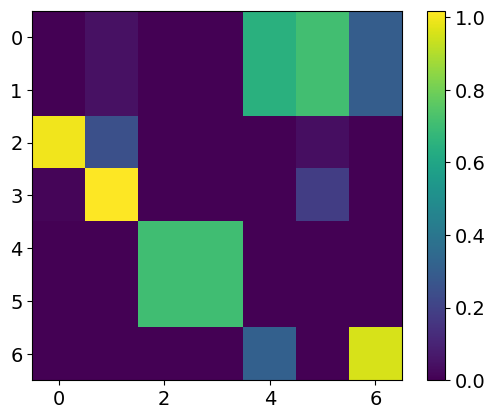

In [98]:
plt.imshow(abs(mf.mo_coeff))
plt.colorbar()

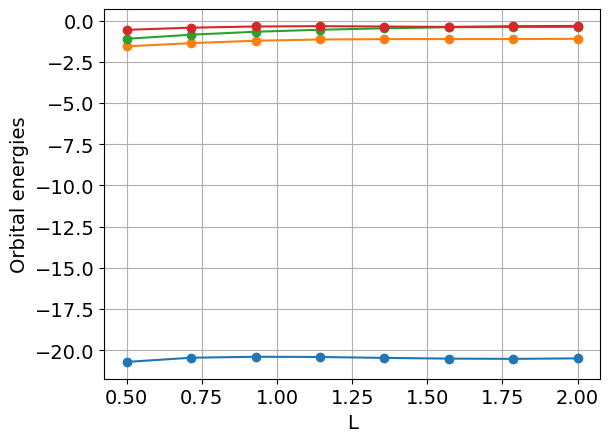

In [8]:
plt.rcParams.update({"font.size":14})
plt.plot(dists, orbenes[0, :], "o-")
plt.plot(dists, orbenes[1, :], "o-")
plt.plot(dists, orbenes[2, :], "o-")
plt.plot(dists, orbenes[3, :], "o-")
# plt.plot(dists, orbenes[4, :], "o-")
# plt.plot(dists, orbenes[5, :], "o-")
# plt.plot(dists, orbenes[1, :] - orbenes[0, :], "o-")
# plt.plot(dists, orbenes[2, :] - orbenes[1, :], "o-")
# plt.plot(dists, orbenes[3, :] - orbenes[2, :], "o-")
plt.xlabel("L")
plt.ylabel("Orbital energies")
# plt.yscale("log")
plt.grid()

In [36]:
dists

array([0.6       , 1.08885714, 1.57771429, 2.06657143, 2.55542857,
       3.04428571, 3.53314286, 4.022     ])